In [1]:

from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [ ]:
import math

class Value:
    def __init__(self, data, children=(), op='', label=''):
        self.data = data
        self._prev = set(children)
        self._op = op
        self.label = label
        self.grad = 0.0
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data={self.data}, label={self._label}, op = {self._op})"
        
    def __add__(self, other):
        other = Value(other) if not isinstance(other, Value) else other
        added = self.data + other.data
        out = Value(added, (self, other), '+')

        def backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = self._backward
        return out
    
    def __radd__(self, other):
        return self + other
    
    def __mul__(self, other):
        other = Value(other) if not isinstance(other, Value) else other
        multed = self.data * other.data
        out = Value(multed, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other
    
    def __pow__(self, other):
        assert isinstance(other, (int, float), 'supporting only int and float powers')
        pow = math.pow(self.data, other) 
        out = Value(pow, (self, ), f'**{other}')

        def _backward():
            self.grad += other * math.pow(self.data, other - 1) * out.grad
        out._backward = _backward
        return out       

    def __neg__(self):
        return self * (-1)
    
    def __sub__(self, other):
        return self + (-other)
        
    def __truediv__(self, other):
        return self * (other**-1)

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward
        return out
        
    def backward(self):
        visited = set()
        topo = []
        def topo_sort(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    topo_sort(child)
                topo.append(v)

        topo_sort(self)
        self.grad = 1.0
        
        for node in reversed(topo):
            node._backward()



In [13]:

# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

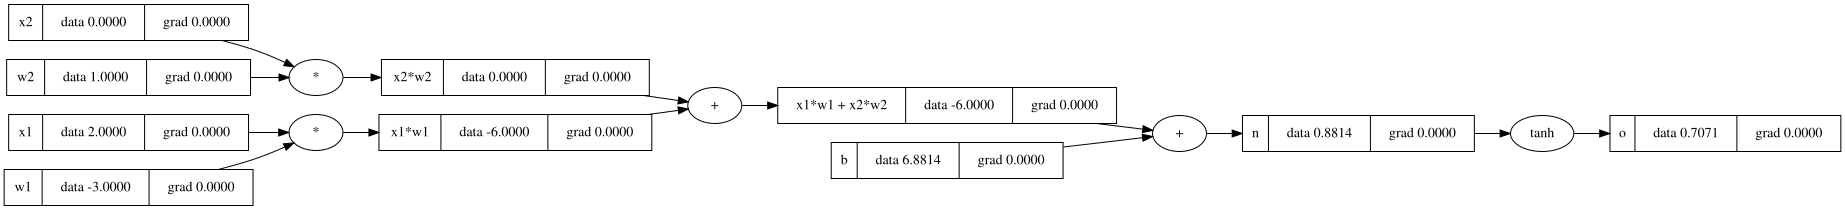

In [14]:
draw_dot(o)

In [19]:
import numpy as np

class Module:
    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0.0

    def parameters(self):
        return []

In [20]:
class Neuron(Module):
    def __init__(self, nin):
        self.weights = [Value(np.random.uniform(-1, 1)) for _ in range(nin)]
        self.bias = Value(np.random.uniform(-1, 1))

    def __call__(self, X):
        out = sum(xi*wi for xi, wi in zip(X, self.weights)) +  self.bias
        return out.tanh()

    def parameters(self):
        return self.weights + [self.bias]

In [ ]:
class Layer(Module):
    def __init__(self, nin, nout):
        self.neurons = [ Neuron(nin) for _ in range(nout)]

    def __call__(self, X):
        outs = [ neuron(X) for neuron in self.neurons]
        return outs
    
    def parameters(self):
        return [ param for n in self.neurons for param in n.parameters()]

In [21]:
class MLP(Module):
    def __init__(self, nin, nouts):
        al = [nin] + nouts
        self.layers = [Layer(al[i], al[i+1])  for i in range(len(nouts))]

    def __call__(self, X):
        out = X
        for layer in self.layers:
            out = layer(X)
        return out
    
    def parameters(self):
        return [ param for layer in self.layers for param in layer.parameters()]